# 🎯 Ejercicios Integradores

Cada ejercicio combina los dos módulos: primero detección clásica,
luego la transformación apropiada para mejorar el análisis.

| Ejercicio | Escenario | Detección | Transformación |
|---|---|---|---|
| **1** | Daños a terceros (severidad con ceros) | IQR + Z-Mod | `arcsinh`, `√x`, `log(x+1)` |
| **2** | Vida grupo por sucursal (frecuencia) | IQR por sucursal | `√x` + `arcsin(√p)` + IC 95% |
| **3** | Hogar: frecuencia + severidad | IQR en ambas dim. | `√x` (freq) + `arcsinh` (sev) |

---
## Ejercicio 1 — Severidad Daños a Terceros con Ceros

**Enunciado**

Una aseguradora tiene 180 siniestros de daños a terceros. Algunos fueron rechazados (monto = 0).

1. Detecta outliers con IQR y Z-Score Modificado en escala original
2. Aplica `√x`, `arcsinh(x/mediana)` y `log(x+1)` a los montos
3. Calcula asimetría (skewness) en cada escala y construye QQ-plots
4. Detecta outliers con IQR en cada escala transformada y compara
5. Calcula la prima pura con y sin outliers
6. ¿Cuál transformación es más apropiada para esta distribución?

**Pista**: Para arcsinh usa como referencia la mediana de los montos > 0.

In [1]:
# Librerias
# ============================================================
# SETUP — Importaciones y funciones base
# (Integra ambos notebooks: detección + transformaciones)
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from scipy.stats import poisson, lognorm, iqr
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (13, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('husl')
np.random.seed(42)

# ── Detección de outliers ──────────────────────────────────────

def detectar_outliers_iqr(serie, factor=1.5):
    """Detección por Rango Intercuartílico."""
    Q1, Q3 = serie.quantile(0.25), serie.quantile(0.75)
    IQR = Q3 - Q1
    li, ls = Q1 - factor*IQR, Q3 + factor*IQR
    return serie < li, serie > ls, li, ls

def detectar_outliers_zscore(serie, umbral=3):
    """Detección por Z-Score clásico."""
    return np.abs(stats.zscore(serie)) > umbral

def detectar_outliers_zscore_mod(serie, umbral=3.5):
    """Detección por Z-Score Modificado (robusto a outliers)."""
    mediana = serie.median()
    MAD = np.median(np.abs(serie - mediana))
    if MAD == 0:
        return pd.Series([False]*len(serie), index=serie.index)
    return 0.6745 * np.abs(serie - mediana) / MAD > umbral

def resumen_outliers(serie, nombre='Variable'):
    """Reporte comparativo de todos los métodos de detección."""
    _, out_iqr, li, ls = detectar_outliers_iqr(serie)
    out_z  = detectar_outliers_zscore(serie)
    out_zm = detectar_outliers_zscore_mod(serie)
    p99    = serie.quantile(0.99)
    print(f"\n{'='*55}")
    print(f"  📊 Resumen de Outliers: {nombre}")
    print(f"{'='*55}")
    print(f"  N total          : {len(serie):,}")
    print(f"  Media            : {serie.mean():,.2f}")
    print(f"  Mediana          : {serie.median():,.2f}")
    print(f"  Desv. Estándar   : {serie.std():,.2f}")
    print(f"  Mín / Máx        : {serie.min():,.2f} / {serie.max():,.2f}")
    print(f"  Percentil 99     : {p99:,.2f}")
    print(f"  Asimetría (skew) : {serie.skew():.3f}")
    print(f"  Curtosis         : {serie.kurtosis():.3f}")
    print(f"\n  --- Outliers detectados ---")
    print(f"  IQR (×1.5)       : {out_iqr.sum():,} ({out_iqr.mean()*100:.1f}%)  [>{ls:,.0f}]")
    print(f"  Z-Score (|z|>3)  : {out_z.sum():,} ({out_z.mean()*100:.1f}%)")
    print(f"  Z-Score Mod.     : {out_zm.sum():,} ({out_zm.mean()*100:.1f}%)")
    print(f"  Capping p99      : {(serie>p99).sum():,} ({(serie>p99).mean()*100:.1f}%)")
    print(f"{'='*55}")
    return {'iqr':out_iqr,'zscore':out_z,'zscore_mod':out_zm,
            'p99':serie>p99,'lim_sup_iqr':ls,'p99_val':p99}

def winsorizar(serie, p_inf=0.0, p_sup=0.99):
    """Winsorización entre percentiles."""
    return serie.clip(lower=serie.quantile(p_inf), upper=serie.quantile(p_sup))

# ── Transformaciones estabilizadoras ──────────────────────────

def t_sqrt(x):
    """Raíz cuadrada. x >= 0."""
    return np.sqrt(np.maximum(x, 0))

def t_arcsin_sqrt(p):
    """Arcoseno de raíz cuadrada. p en [0,1]."""
    return np.arcsin(np.sqrt(np.clip(p, 0, 1)))

def t_arcsinh(x, escala=1.0):
    """Arcoseno hiperbólico escalado. Funciona en x=0."""
    return np.arcsinh(x / escala)

def qqplot_ax(ax, data, titulo, color='#4C9BE8'):
    """QQ-plot Normal sobre un eje dado."""
    (osm, osr), (slope, intercept, r) = stats.probplot(data, dist='norm')
    ax.scatter(osm, osr, color=color, alpha=0.5, s=18, edgecolors='none')
    xl = np.array([min(osm), max(osm)])
    ax.plot(xl, slope*xl+intercept, 'r-', lw=2, label=f'R²={r**2:.3f}')
    ax.set_title(titulo, fontsize=10)
    ax.legend(fontsize=8)
    ax.set_xlabel('Cuantiles teóricos')
    ax.set_ylabel('Cuantiles observados')

print('✅ Setup completo — funciones de detección y transformación listas')

✅ Setup completo — funciones de detección y transformación listas


N total    : 180
Ceros      : 10
No-ceros   : 170
Skewness   : 4.522
Max        : $200,000
Comparación de detección de outliers en distintas escalas:
Escala        IQR (n)   IQR (%)  Z-Mod (n)  Z-Mod (%)
------------------------------------------------------------
original           13      7.2%         13       7.2%
√x                 12      6.7%         11       6.1%
arcsinh            11      6.1%         10       5.6%
log(x+1)           10      5.6%         20      11.1%
------------------------------------------
Asimetría (skewness) por transformación:
------------------------------------------
  Sin transformar               : skew=+4.522
  √x                            : skew=+3.300
  arcsinh(x/mediana)            : skew=+2.321
  log(x+1)                      : skew=-2.411

 Conclusiones:
 La transformación arcsinh(x/mediana) es la que más reduce la asimetría, además de que detecta menos outliers extremos que las demás escalas,
 además en el QQ-plot se observa un mejor ajuste a

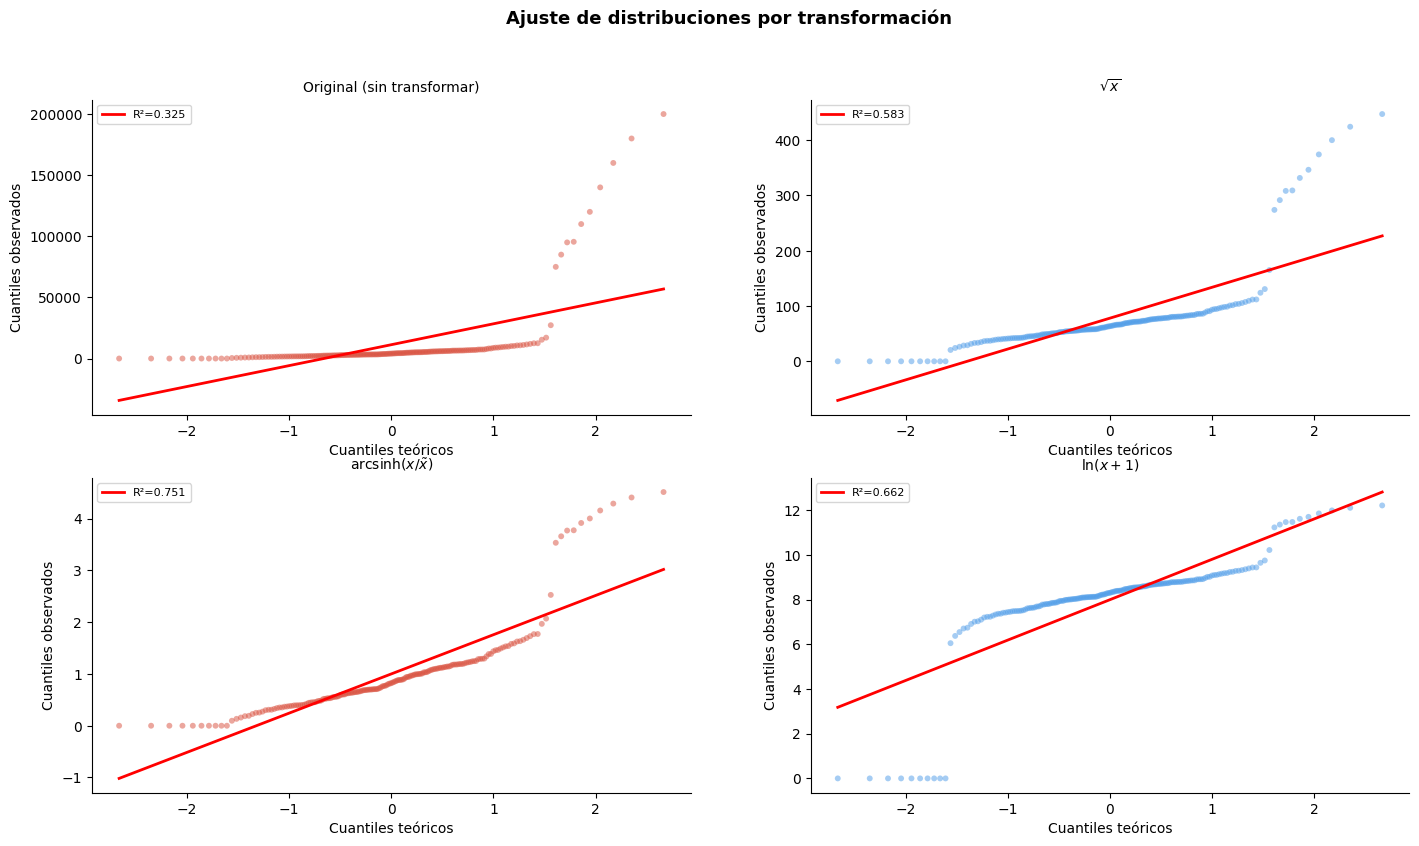

In [2]:
# ============================================================
# EJERCICIO 1 — Datos (no modificar)
# ============================================================
np.random.seed(99)
siniestros_base = np.random.lognormal(8.2, 0.7, 160)
siniestros_altos = np.array([95_000,120_000,85_000,140_000,200_000,
                               75_000,160_000,110_000,180_000,95_500])
ceros_ej1 = np.zeros(10)   # siniestros rechazados

siniestros_ej1 = pd.Series(
    np.concatenate([siniestros_base, siniestros_altos, ceros_ej1])
).round(2)

print(f'N total    : {len(siniestros_ej1)}')
print(f'Ceros      : {(siniestros_ej1==0).sum()}')
print(f'No-ceros   : {(siniestros_ej1>0).sum()}')
print(f'Skewness   : {siniestros_ej1.skew():.3f}')
print(f'Max        : ${siniestros_ej1.max():,.0f}')

# ============================================================
# TU CÓDIGO AQUÍ ↓
# ============================================================

# Paso 1: Calcular transformaciones
# Recuerda: log(0) falla → usa log(x+1) o arcsinh
# ref_ej1 = siniestros_ej1[siniestros_ej1 > 0].median()  # referencia arcsinh
# sqrt_ej1       = ...
# arcsinh_ej1    = ...
# log1p_ej1      = ...  # log(x+1) para manejar ceros

# 1. Detectar outliers con IQR y Z-score Modificado en la escala original
# Usamos las funciones que definimos antes:
_, out_iqr, li, ls = detectar_outliers_iqr(siniestros_ej1)
out_zm = detectar_outliers_zscore_mod(siniestros_ej1)

# 2. Realizamos transformaciones √x, arcsinh(x/mediana) y log(x+1)

sqrt_ej1       = t_sqrt(siniestros_ej1)
arcsinh_ej1    = t_arcsinh(siniestros_ej1, escala=siniestros_ej1[siniestros_ej1 > 0].median())
log1p_ej1      = np.log1p(siniestros_ej1)  # Como hay ceros, usamos log(x+1) y evitamos log(0)

# Observamos resultados de outliers en escala original y transfirnaciones

resultados_deteccion = {}
for label, data in [('original',siniestros_ej1), ('√x',sqrt_ej1),
                    ('arcsinh', arcsinh_ej1), ('log(x+1)',log1p_ej1)]:
    _, out_iqr, _, lim_s = detectar_outliers_iqr(data)
    out_zm = detectar_outliers_zscore_mod(data)
    resultados_deteccion[label] = {
        'IQR_n': out_iqr.sum(), 'IQR_pct': out_iqr.mean()*100,
        'ZMod_n': out_zm.sum(), 'ZMod_pct': out_zm.mean()*100
    }

df_det = pd.DataFrame(resultados_deteccion).T
print('='*60)
print('Comparación de detección de outliers en distintas escalas:')
print('='*60)
print(f'{"Escala":<12} {"IQR (n)":>8} {"IQR (%)":>9} {"Z-Mod (n)":>10} {"Z-Mod (%)":>10}')
print('-'*60)
for idx, row in df_det.iterrows():
    print(f'{idx:<12} {row.IQR_n:>8.0f} {row.IQR_pct:>8.1f}% {row.ZMod_n:>10.0f} {row.ZMod_pct:>9.1f}%') 


# Paso 2: Asimetría por escala
# Obtenemos la asimetria para cada una de las escalas.
# Creamos un DataFrame con todas las escalas calculadas anteriormente
transf = pd.DataFrame({
    'original'     : siniestros_ej1,
    'sqrt'         : sqrt_ej1,
    'arcsinh'      : arcsinh_ej1,
    'log'          : log1p_ej1        # referencia clásica
})

# Iniciamos con el resumen de asimetrías
print('-'*42)
print('Asimetría (skewness) por transformación:')
print('-'*42)
# Indicamos el nombre de cada escala 
labels = {
    'original'   : 'Sin transformar',
    'sqrt'       : '√x',
    'arcsinh'    : 'arcsinh(x/mediana)',
    'log'        : 'log(x+1)'
}
# Calculamos la asimetria y mostramos el resultado.
for col, label in labels.items():
    sk = transf[col].skew()
    print(f'  {label:<30}: skew={sk:+.3f}')

# ...

# Paso 3: QQ-Plots (2x2)
# ...
# Cramos una figura de 2x2 para mostrar los QQ-plots de cada escala.
fig, axes = plt.subplots(2, 2, figsize=(17, 9))
# Titulo general del gráfico
fig.suptitle('Ajuste de distribuciones por transformación',
             fontsize=13, fontweight='bold')
# Definimos las configuraciones para cada escala: nombre de la columna, título del gráfico y color.
configs = [
    ('original',    'Original (sin transformar)',  '#D94F3D'),
    ('sqrt',        '$\\sqrt{x}$',                 '#4C9BE8'),
    ('arcsinh',     '$\\text{arcsinh}(x/\\tilde{x})$', '#D94F3D'),
    ('log',         '$\\ln(x+1)$',     '#4C9BE8'),
]

# Iteramos sobre cada entrada de configuración y el eje correspondiente para crear los QQ-plots.
axes_flat = axes.flat
# La función qqplot_ax es la que definimos antes para crear un QQ-plot en un eje dado.
for (col, titulo, color), ax in zip(configs, axes_flat):
    qqplot_ax(ax, transf[col], titulo, color)

# Paso 4: Detección outliers IQR en cada escala
# ...
# En el paso 1 ya calculamos y mostramos la detección de outliers para cada escala. 


# Paso 5: Conclusión
# ...
print('\n Conclusiones:')
print(' La transformación arcsinh(x/mediana) es la que más reduce la asimetría, además de que detecta menos outliers extremos que las demás escalas,\n'
      ' además en el QQ-plot se observa un mejor ajuste a la normal y esta tranformación puede manejar los ceros que tiene la la data.')


  📊 Resumen de Outliers: Siniestros Daños a Terceros (MXN)
  N total          : 180
  Media            : 11,311.57
  Mediana          : 4,029.78
  Desv. Estándar   : 29,687.60
  Mín / Máx        : 0.00 / 200,000.00
  Percentil 99     : 164,200.00
  Asimetría (skew) : 4.522
  Curtosis         : 20.903

  --- Outliers detectados ---
  IQR (×1.5)       : 13 (7.2%)  [>12,851]
  Z-Score (|z|>3)  : 6 (3.3%)
  Z-Score Mod.     : 13 (7.2%)
  Capping p99      : 2 (1.1%)


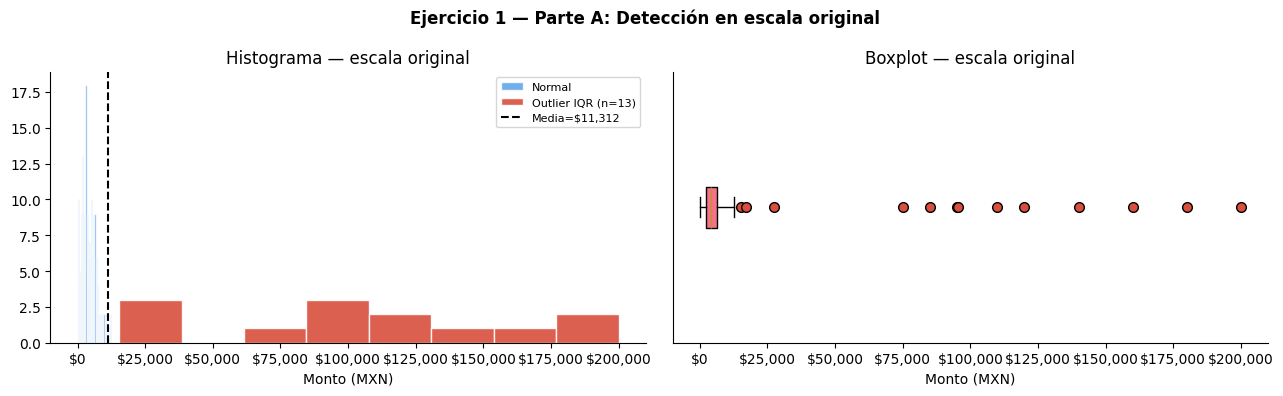


→ Continúa en la siguiente celda con las transformaciones (Parte B)


In [3]:
# ── PARTE A: Detección clásica en escala original ────────────
res_e1_orig = resumen_outliers(siniestros_ej1, 'Siniestros Daños a Terceros (MXN)')

# Visualización rápida
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
_, out_e1, _, ls_e1 = detectar_outliers_iqr(siniestros_ej1)
ax[0].hist(siniestros_ej1[~out_e1], bins=30, color='#4C9BE8', alpha=0.8,
           label='Normal', edgecolor='white')
ax[0].hist(siniestros_ej1[out_e1],  bins=8,  color='#D94F3D', alpha=0.9,
           label=f'Outlier IQR (n={out_e1.sum()})', edgecolor='white')
ax[0].axvline(siniestros_ej1.mean(), color='k', ls='--', lw=1.5,
              label=f'Media=${siniestros_ej1.mean():,.0f}')
ax[0].set_title('Histograma — escala original')
ax[0].set_xlabel('Monto (MXN)')
ax[0].legend(fontsize=8)
ax[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x,p: f'${x:,.0f}'))

ax[1].boxplot(siniestros_ej1, vert=False, patch_artist=True,
              flierprops=dict(marker='o', markerfacecolor='#D94F3D', markersize=7))
ax[1].set_title('Boxplot — escala original')
ax[1].set_xlabel('Monto (MXN)')
ax[1].set_yticks([])
ax[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x,p: f'${x:,.0f}'))
plt.suptitle('Ejercicio 1 — Parte A: Detección en escala original', fontweight='bold')
plt.tight_layout(); plt.show()

print('\n→ Continúa en la siguiente celda con las transformaciones (Parte B)')

---
## Ejercicio 2 — Frecuencia de Incapacidad por Sucursal

**Enunciado**

Seguro de vida grupo, **120 empleados** en 5 sucursales. Variable: días de incapacidad/año.

1. Detecta sucursales con frecuencia atípica usando IQR global
2. Aplica `√x` a días individuales y re-detecta outliers
3. Calcula la tasa relativa por sucursal: $p_j = \bar{x}_j / \max(\bar{x})$
4. Aplica `arcsin(√p_j)` y construye IC al 95% con varianza estabilizada $\approx 1/(4n_j)$
5. ¿Qué sucursales son estadísticamente atípicas? ¿El resultado cambia con la transformación?

In [4]:
# ============================================================
# EJERCICIO 2 — Datos provistos
# ============================================================
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots


np.random.seed(77)

n_empleados = 120
sucursales = np.random.choice(['Norte', 'Sur', 'Este', 'Oeste', 'Centro'],
                               n_empleados)

# Siniestros de incapacidad (días ausentes en el año)
dias_base = {'Norte': 3, 'Sur': 4, 'Este': 5, 'Oeste': 3, 'Centro': 12}  # Centro es alta frecuencia
num_siniestros_ej2 = np.array([
    np.random.poisson(dias_base[s]) for s in sucursales
])

df_vida_grupo = pd.DataFrame({
    'Empleado_ID': range(1, n_empleados+1),
    'Sucursal': sucursales,
    'Dias_Incapacidad': num_siniestros_ej2
})

print(f'Dataset: {len(df_vida_grupo)} empleados en {df_vida_grupo.Sucursal.nunique()} sucursales')
print('\nResumen por sucursal:')
print(df_vida_grupo.groupby('Sucursal')['Dias_Incapacidad'].describe().round(2))
print('-'*50)

# ============================================================
# TU CÓDIGO AQUÍ ↓
# ============================================================

# 1. Detectar sucursales con frecuencia atípica
# ...
# Detectamos outliers en la variables 'Dias Incapacidad' con la funcion IQR
_, out_sucursal_iqr_2, _, _ = detectar_outliers_iqr(df_vida_grupo['Dias_Incapacidad'])

# Mostramos el número de empleados con días de incapacidad atípicos según IQR
print(f'Empleados con días de incapacidad atípicos (IQR): {out_sucursal_iqr_2.sum()} ({(out_sucursal_iqr_2.mean()*100):.1f}%)')
# Mostramos las sucursales atípicas según la detección de outliers IQR
print('Sucursales atípicas:', df_vida_grupo.loc[out_sucursal_iqr_2, 'Sucursal'].unique())

#Aplicamos √x a los días de incapacidad para reducir la asimetría y detectar outliers en esta escala transformada
sqrt_ej2 = t_sqrt(df_vida_grupo['Dias_Incapacidad'])

_, out_sqrt, _, _ = detectar_outliers_iqr(sqrt_ej2)
print(f'Transformación √x — Empleados con días de incapacidad atípicos (IQR): {out_sqrt.sum()} ({(out_sqrt.mean()*100):.1f}%)')
print('Sucursales atípicas tras √x:', df_vida_grupo.loc[out_sqrt, 'Sucursal'].unique())

# 2. Tasa de siniestralidad por sucursal
# ...
# Calcularemos la tasa de siniestralidad relativa a cada sucursal.
# ESTA PARTE DEL EJERCICIO NO ME QUEDA CLARA DEL TODO.
# La tasa se definde como $p_j = \bar{x}_j / \max(\bar{x})$
# Calculamos la media de días ppor sucursal
tasa_siniestralidad_sucursal = df_vida_grupo.groupby('Sucursal').agg(Media_sucursal = ('Dias_Incapacidad', 'mean'),
                                                                      n = ('Empleado_ID', 'count')).reset_index()
# Calculamos la tasa relativa dividiendo la media de cada sucursal por la media máxima entre las sucursales
tasa_siniestralidad_sucursal['Tasa_relativa'] = tasa_siniestralidad_sucursal['Media_sucursal'] / tasa_siniestralidad_sucursal['Media_sucursal'].max()
# Mostramos la tasa de siniestralidad relativa por sucursal
print('\nTasa de siniestralidad relativa por sucursal:')
print(tasa_siniestralidad_sucursal[['Tasa_relativa']].round(3))

# Aplicamos la transformación arcsin(√p) a las tasas relativas
tasa_siniestralidad_sucursal['tasa_arcsin'] = np.arcsin(np.sqrt(tasa_siniestralidad_sucursal['Tasa_relativa']))

# Calculamos la varianza estabilizada tras arcsin(√p) que es aproximadamente constante: Var ≈ 1/(4n)
tasa_siniestralidad_sucursal['varianza_estabilizada'] = np.sqrt(1 / (4 * tasa_siniestralidad_sucursal['n']))

# Asumiendo normalidad tras la transformación, calculamos interavlos de confianza al 95% para cada sucursal
tasa_siniestralidad_sucursal['ci'] = 1.96 * tasa_siniestralidad_sucursal['varianza_estabilizada']

# Calculamos los límites inferior y superior del intervalo de confianza para la tasa transformada
tasa_siniestralidad_sucursal['lower'] = tasa_siniestralidad_sucursal['tasa_arcsin'] - tasa_siniestralidad_sucursal['ci']
tasa_siniestralidad_sucursal['upper'] = tasa_siniestralidad_sucursal['tasa_arcsin'] + tasa_siniestralidad_sucursal['ci']

# 3. Visualización
# ...
# Visualizamos las tasas transformadas con sus intervalos de confianza para comparar entre sucursales.
fig = px.scatter(
    tasa_siniestralidad_sucursal,
    x='Sucursal',
    y='tasa_arcsin',
    error_y='ci',
    color='Sucursal'
)
fig.show()

# 4. Conclusión
# ...
print('\nConclusión:')
print('La sucursal Centro tiene una tasa de siniestralidad muy superior a las demás, incluso despues de aplicar la transformación arcsin(√p) \n'
      'lo que indica que esta sucursal es estadisticamente atípica en términos de días de incapacidad.')

Dataset: 120 empleados en 5 sucursales

Resumen por sucursal:
          count   mean   std  min   25%   50%   75%   max
Sucursal                                                 
Centro     32.0  12.41  3.56  7.0  9.75  13.0  14.0  19.0
Este       19.0   5.00  2.13  1.0  3.00   6.0   6.5   8.0
Norte      19.0   2.95  1.65  0.0  2.00   3.0   4.0   6.0
Oeste      25.0   3.52  2.08  0.0  2.00   4.0   5.0   8.0
Sur        25.0   4.40  2.36  1.0  3.00   4.0   5.0  10.0
--------------------------------------------------
Empleados con días de incapacidad atípicos (IQR): 5 (4.2%)
Sucursales atípicas: ['Centro']
Transformación √x — Empleados con días de incapacidad atípicos (IQR): 0 (0.0%)
Sucursales atípicas tras √x: []

Tasa de siniestralidad relativa por sucursal:
   Tasa_relativa
0          1.000
1          0.403
2          0.238
3          0.284
4          0.355



Conclusión:
La sucursal Centro tiene una tasa de siniestralidad muy superior a las demás, incluso despues de aplicar la transformación arcsin(√p) 
lo que indica que esta sucursal es estadisticamente atípica en términos de días de incapacidad.


---
## Ejercicio 3 — Seguro de Hogar: Frecuencia + Severidad + Transformaciones

**Enunciado**

Portafolio de **130 pólizas** de hogar. Algunas pólizas no tuvieron siniestros (monto = 0).

1. Detecta outliers de frecuencia (IQR) y severidad (IQR) en escala original
2. Calcula la prima pura en 4 escenarios (con/sin outliers en cada dimensión)
3. Aplica `√x` a frecuencia y `arcsinh(x/mediana)` a severidad
4. Construye tabla comparativa de asimetría/curtosis antes y después
5. Detecta doble outlier en escala transformada: ¿coincide con el original?
6. Discute la **desigualdad de Jensen**: ¿puedes usar la media arcsinh para calcular la prima?

In [5]:
# ============================================================
# EJERCICIO 3 — Datos provistos
# ============================================================

np.random.seed(55)
n_polizas = 130

# Frecuencia: Poisson(1.5) con algunos outliers
freq_hogar = pd.Series(
    np.concatenate([
        np.random.poisson(1.5, 120),
        np.array([8, 10, 7, 9, 12, 6, 11, 8, 9, 7])
    ])
)

# Severidad promedio por póliza (MXN)
sev_hogar = pd.Series(
    np.concatenate([
        np.random.lognormal(9.0, 0.6, 120),
        np.array([450_000, 380_000, 520_000, 310_000, 600_000,
                  290_000, 475_000, 350_000, 410_000, 550_000])
    ])
).round(2)

df_hogar = pd.DataFrame({
    'Poliza_ID': range(1, n_polizas + 1),
    'Num_Siniestros': freq_hogar,
    'Monto_Promedio_MXN': sev_hogar
})
df_hogar['Costo_Total'] = df_hogar['Num_Siniestros'] * df_hogar['Monto_Promedio_MXN']

print(f'Dataset: {len(df_hogar)} pólizas de hogar')
print('\nEstadísticas:')
print(df_hogar.describe().round(2))
print('-'*50)

# ============================================================
# TU CÓDIGO AQUÍ ↓
# ============================================================

# 1. Outliers de frecuencia
# ...
# Detectamos outliers en la variable 'Num_Siniestros' utilizando la función IQR
_, out_freq_iqr, _, _ = detectar_outliers_iqr(df_hogar['Num_Siniestros'])
print(f'Pólizas con número de siniestros atípico (IQR): {out_freq_iqr.sum()} ({(out_freq_iqr.mean()*100):.1f}%)')
print('Pólizas atípicas por frecuencia:', df_hogar.loc[out_freq_iqr, 'Poliza_ID'].tolist())

# 2. Outliers de severidad
# ...
# Detectamos outliers en la variable 'Monto_Promedio_MXN' utilizando la función IQR
_, out_sev_iqr, _, _ = detectar_outliers_iqr(df_hogar['Monto_Promedio_MXN'])
print(f'Pólizas con monto promedio atípico (IQR): {out_sev_iqr.sum()} ({(out_sev_iqr.mean()*100):.1f}%)')
print('Pólizas atípicas por severidad:', df_hogar.loc[out_sev_iqr, 'Poliza_ID'].tolist())

# Polizas que son outliers en ambas dimensiones (frecuencia y severidad)
out_both = out_freq_iqr & out_sev_iqr
print(f'Pólizas con frecuencia y severidad atípicas: {out_both.sum()} ({(out_both.mean()*100):.1f}%)')
print('Pólizas atípicas en ambas dimensiones:', df_hogar.loc[out_both, 'Poliza_ID'].tolist())
print('-'*50)

# 3. Prima pura en 4 escenarios
# ...
# Calculamos la prima pura bajo diferentes escenarios de manejo de outliers 
def calcular_prima_pura(df_frec, df_sev):
    # Obtenemos la tasa de frecuencia y la severidad promedio para calcular la prima pura
    frec = df_frec['Num_Siniestros'].sum()/len(df_frec)
    sev = df_sev[df_sev['Monto_Promedio_MXN'] > 0]['Monto_Promedio_MXN'].mean()
    # La prima pura se calcula como la multiplicación de la frecuencia por la severidad
    return frec * sev

# Escenario 1: Sin eliminar outliers
prima_sin_eliminar = calcular_prima_pura(df_hogar, df_hogar)
# Escenario 2: Eliminando outliers de frecuencia
prima_sin_out_freq = calcular_prima_pura(df_hogar[~out_freq_iqr], df_hogar)
# Escenario 3: Eliminando outliers de severidad
prima_sin_out_sev = calcular_prima_pura(df_hogar, df_hogar[~out_sev_iqr])
# Escenario 4: Eliminando outliers en ambas dimensiones
prima_sin_out_both = calcular_prima_pura(df_hogar[~out_freq_iqr], df_hogar[~out_sev_iqr])
# Mostamos los resultados
print('Prima pura bajo diferentes escenarios:')
print(f'1. Sin eliminar outliers: ${prima_sin_eliminar:,.2f}')
print(f'2. Eliminando outliers de frecuencia: ${prima_sin_out_freq:,.2f}')
print(f'3. Eliminando outliers de severidad: ${prima_sin_out_sev:,.2f}')
print(f'4. Eliminando outliers en ambas dimensiones: ${prima_sin_out_both:,.2f}')
print('-'*50)

# Aplicar √x a frecuencia y arcsinh(x/mediana) a severidad
df_hogar['Num_Siniestros_Sqrt'] = t_sqrt(df_hogar['Num_Siniestros'])
df_hogar['Monto_Promedio_Arcsinh'] = t_arcsinh(df_hogar['Monto_Promedio_MXN'], escala=df_hogar[df_hogar['Monto_Promedio_MXN'] > 0]['Monto_Promedio_MXN'].median())

# Comparamos la asimetría y curtosis antes y después de las transformaciones
# Creamos un DataFrame con las columnas originales y Transformadas
transf = pd.DataFrame({
    'Frecuencia Original'     : df_hogar['Num_Siniestros'],
    'Frecuencia √x'         : df_hogar['Num_Siniestros_Sqrt'],
    'Severidad Original'    : df_hogar['Monto_Promedio_MXN'],
    'Severidad arcsinh'     : df_hogar['Monto_Promedio_Arcsinh']
})

# Iniciamos con el resumen de asimetrías y curtosis para cada escala
print('Asimetría (skewness) por transformación:')
print('-'*42)
# Indicamos el nombre de cada escala para mostrar los resultados de asimetría y curtosis.
labels = {
    'Frecuencia Original'   : 'Frecuencia original',
    'Frecuencia √x'       : '√x',
    'Severidad Original'    : 'Severidad original',
    'Severidad arcsinh'     : 'arcsinh(x/mediana)'
}
# Calculamos la asimetria y curtosis para cada escala y mostramos el resultado.
for col, label in labels.items():
    sk = transf[col].skew()
    kurt = transf[col].kurtosis()
    print(f'  {label:<30}: skew={sk:+.3f}  kurt={kurt:+.3f}')

print('-'*50)

# 4. Pólizas con doble outlier
# ...

# Detectamos outliers en la variable 'Num_Siniestros_Sqrt' utilizando la función IQR
_, out_freq_iqr_trans, _, _ = detectar_outliers_iqr(df_hogar['Num_Siniestros_Sqrt'])
print(f'Pólizas con número de siniestros atípico (IQR) Transformada: {out_freq_iqr_trans.sum()} ({(out_freq_iqr_trans.mean()*100):.1f}%)')
print('Pólizas atípicas por frecuencia:', df_hogar.loc[out_freq_iqr_trans, 'Poliza_ID'].tolist())

# 2. Outliers de severidad
# Detectamos outliers en la variable 'Monto_Promedio_Arcsinh' utilizando la función IQR
_, out_sev_iqr_trans, _, _ = detectar_outliers_iqr(df_hogar['Monto_Promedio_Arcsinh'])
print(f'Pólizas con monto promedio atípico (IQR) Transformada: {out_sev_iqr_trans.sum()} ({(out_sev_iqr_trans.mean()*100):.1f}%)')
print('Pólizas atípicas por severidad:', df_hogar.loc[out_sev_iqr_trans, 'Poliza_ID'].tolist())

# Polizas que son outliers en ambas dimensiones (frecuencia y severidad)
out_both = out_freq_iqr_trans & out_sev_iqr_trans
print(f'Pólizas con frecuencia y severidad atípicas transformadas: {out_both.sum()} ({(out_both.mean()*100):.1f}%)')
print('Pólizas atípicas en ambas dimensiones:', df_hogar.loc[out_both, 'Poliza_ID'].tolist())
print('-'*50)
print(' La polizas atipicas en ambas dimensiones (frecuencia y severidad) no cambian mucho antes y después de las transformaciones, lo que indica que las transformaciones no afectaron la detección de estas pólizas atípicas en este caso específico.')

# 6. Discute la **desigualdad de Jensen**: ¿puedes usar la media arcsinh para calcular la prima?




Dataset: 130 pólizas de hogar

Estadísticas:
       Poliza_ID  Num_Siniestros  Monto_Promedio_MXN  Costo_Total
count     130.00          130.00              130.00       130.00
mean       65.50            2.01            41788.53    306729.88
std        37.67            2.29           116951.19   1095056.71
min         1.00            0.00             2512.53         0.00
25%        33.25            1.00             5307.03      4217.53
50%        65.50            1.00             8424.76     10984.94
75%        97.75            2.00            11782.46     21785.43
max       130.00           12.00           600000.00   7200000.00
--------------------------------------------------
Pólizas con número de siniestros atípico (IQR): 18 (13.8%)
Pólizas atípicas por frecuencia: [8, 17, 56, 73, 86, 107, 108, 119, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130]
Pólizas con monto promedio atípico (IQR): 13 (10.0%)
Pólizas atípicas por severidad: [27, 67, 110, 121, 122, 123, 124, 125, 126, 127,

### 6. Discute la **desigualdad de Jensen**: ¿puedes usar la media arcsinh para calcular la prima?

La desigualdad de Jensen indica lo siguiente:

Si una función es convexa (cóncava hacia arriba), se tiene que $E[f(X)] \geq f(E[X])$. Si la función es cóncava (cóncava hacia abajo), el sentido de la desigualdad se invierte. 

Sabemos que la función arcsin es cóncava en el dominio que estamos utilizando (siniestros son mayores que 0), por lo que la desigualdad quedaria de la siguiente forma:

$$ E[f(X)] \leq f(E[X])$$

si decimos que la prima se calcula con el $arcsinh(X)$ (ajustandole una distribución a la transformación), tendriamos que tomar su inversa para la prima, entonces tendriamos la siguiente igualdad:

$$P = \sinh(E[arcsinh(X)])$$


Ahora si aplicamos la desigualdan de Jensen con la función $arcsinh$, tenemos lo siguiente:

$$E[arcsinh(X)] \leq arcsinh(E[X])$$

si aplicamos la función inversa a la desigualdad tendriamos:

$$\sinh(E[arcsinh(X)]) \leq \sinh(arcsinh(E[X]))$$

Entonces:

$$P \leq E[X]$$

Esto indica que la prima es menor al valor esperado de pérdida, por lo que estariamos subestimando el riesgo y no es viable para una aseguradora.

En el caso de usar una tranformación que sea convexa, estariamos sobreestimando el riesgo, lo que aseguraria solvencia por parte de la aseguradora, pero eso haria que nuestros precios no sean competitivos en el mercado. Entonces tengo una duda ¿cuándo conviene aplicar transformaciones para calcular la prima de riesgo?

